In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv(r"/content/5. London Housing Data (1).csv")

df

,date,area,average_price,code,houses_sold,no_of_crimes
0,1/1/1995,city of london,91449,E09000001,17.0,NaN
1,2/1/1995,city of london,82203,E09000001,7.0,NaN
2,3/1/1995,city of london,79121,E09000001,14.0,NaN
3,4/1/1995,city of london,77101,E09000001,7.0,NaN
4,5/1/1995,city of london,84409,E09000001,10.0,NaN
...,...,...,...,...,...,...
13544,9/1/2019,england,249942,E92000001,64605.0,NaN
13545,10/1/2019,england,249376,E92000001,68677.0,NaN
13546,11/1/2019,england,248515,E92000001,67814.0,NaN
13547,12/1/2019,england,250410,E92000001,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13549 entries, 0 to 13548
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           13549 non-null  object 
 1   area           13549 non-null  object 
 2   average_price  13549 non-null  int64  
 3   code           13549 non-null  object 
 4   houses_sold    13455 non-null  float64
 5   no_of_crimes   7439 non-null   float64
dtypes: float64(2), int64(1), object(3)
memory usage: 635.2+ KB


In [ ]:
df['date'] = pd.to_datetime(df['date'])
df['average_price'] = df['average_price'].astype(float)
# df.drop(columns='code', inplace=True)

In [ ]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

df = df.sort_values(by=['area', 'date']).reset_index(drop=True)
df

,date,area,average_price,code,houses_sold,no_of_crimes,year,month
0,1995-01-01,barking and dagenham,50460.0,E09000002,96.0,NaN,1995,1
1,1995-02-01,barking and dagenham,51086.0,E09000002,95.0,NaN,1995,2
2,1995-03-01,barking and dagenham,51269.0,E09000002,144.0,NaN,1995,3
3,1995-04-01,barking and dagenham,53134.0,E09000002,109.0,NaN,1995,4
4,1995-05-01,barking and dagenham,53042.0,E09000002,149.0,NaN,1995,5
...,...,...,...,...,...,...,...,...
13544,2019-09-01,yorks and the humber,165362.0,E12000003,6567.0,NaN,2019,9
13545,2019-10-01,yorks and the humber,166669.0,E12000003,7163.0,NaN,2019,10
13546,2019-11-01,yorks and the humber,164530.0,E12000003,7117.0,NaN,2019,11
13547,2019-12-01,yorks and the humber,166932.0,E12000003,NaN,NaN,2019,12


In [2]:
# shift 12 months for one year
df['previous_year_average'] = df.groupby('area')['average_price'].shift(12)
df['YoY_growth_avg_price'] = (df['average_price'] - df['previous_year_average']) / df['previous_year_average']

df.head(15)

NameError: name 'df' is not defined

In [ ]:
df['previous_month_average'] = df.groupby('area')['average_price'].shift(1)
df['MoM_growth_avg_price'] = (df['average_price'] - df['previous_month_average']) / df['previous_month_average']

df.head(10)

,date,area,average_price,code,houses_sold,no_of_crimes,year,month,previous_year_average,YoY_growth_avg_price,previous_month_average,MoM_growth_avg_price
0,1995-01-01,barking and dagenham,50460.0,E09000002,96.0,NaN,1995,1,NaN,NaN,NaN,NaN
1,1995-02-01,barking and dagenham,51086.0,E09000002,95.0,NaN,1995,2,NaN,NaN,50460.0,0.012406
2,1995-03-01,barking and dagenham,51269.0,E09000002,144.0,NaN,1995,3,NaN,NaN,51086.0,0.003582
3,1995-04-01,barking and dagenham,53134.0,E09000002,109.0,NaN,1995,4,NaN,NaN,51269.0,0.036377
4,1995-05-01,barking and dagenham,53042.0,E09000002,149.0,NaN,1995,5,NaN,NaN,53134.0,-0.001731
5,1995-06-01,barking and dagenham,53700.0,E09000002,148.0,NaN,1995,6,NaN,NaN,53042.0,0.012405
6,1995-07-01,barking and dagenham,52113.0,E09000002,117.0,NaN,1995,7,NaN,NaN,53700.0,-0.029553
7,1995-08-01,barking and dagenham,52232.0,E09000002,150.0,NaN,1995,8,NaN,NaN,52113.0,0.002283
8,1995-09-01,barking and dagenham,51472.0,E09000002,112.0,NaN,1995,9,NaN,NaN,52232.0,-0.014550
9,1995-10-01,barking and dagenham,51514.0,E09000002,120.0,NaN,1995,10,NaN,NaN,51472.0,0.000816


In [ ]:
df.info(0)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13549 entries, 0 to 13548
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   date                    13549 non-null  datetime64[ns]
 1   area                    13549 non-null  object        
 2   average_price           13549 non-null  float64       
 3   code                    13549 non-null  object        
 4   houses_sold             13455 non-null  float64       
 5   no_of_crimes            7439 non-null   float64       
 6   year                    13549 non-null  int32         
 7   month                   13549 non-null  int32         
 8   previous_year_average   13009 non-null  float64       
 9   YoY_growth_avg_price    13009 non-null  float64       
 10  previous_month_average  13504 non-null  float64       
 11  MoM_growth_avg_price    13504 non-null  float64       
dtypes: datetime64[ns](1), float64(7), int32(2), ob

Text(0.5, 1.0, 'Correlation Between Crime & Average Price')

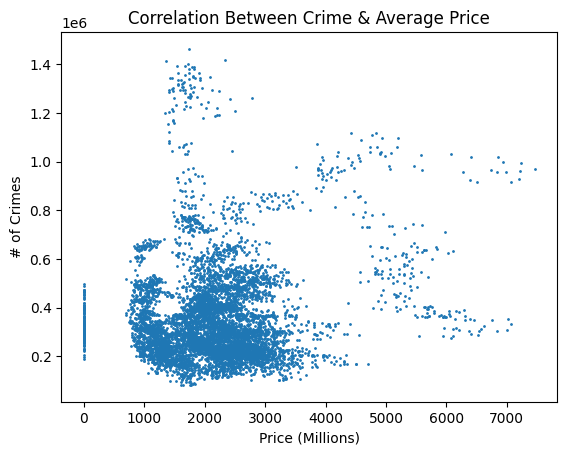

In [ ]:
plt.scatter(x=df['no_of_crimes'], y=df['average_price'], s=1)

plt.xlabel("Price (Millions)")
plt.ylabel("# of Crimes")
plt.title("Correlation Between Crime & Average Price")

In [ ]:
df.to_excel('clean_london_housing_data.xlsx', index=False)

In [ ]:
df

,date,area,average_price,code,houses_sold,no_of_crimes,year,month,previous_year_average,YoY_growth_avg_price,previous_month_average,MoM_growth_avg_price
0,1995-01-01,barking and dagenham,50460.0,E09000002,96.0,NaN,1995,1,NaN,NaN,NaN,NaN
1,1995-02-01,barking and dagenham,51086.0,E09000002,95.0,NaN,1995,2,NaN,NaN,50460.0,0.012406
2,1995-03-01,barking and dagenham,51269.0,E09000002,144.0,NaN,1995,3,NaN,NaN,51086.0,0.003582
3,1995-04-01,barking and dagenham,53134.0,E09000002,109.0,NaN,1995,4,NaN,NaN,51269.0,0.036377
4,1995-05-01,barking and dagenham,53042.0,E09000002,149.0,NaN,1995,5,NaN,NaN,53134.0,-0.001731
...,...,...,...,...,...,...,...,...,...,...,...,...
13544,2019-09-01,yorks and the humber,165362.0,E12000003,6567.0,NaN,2019,9,162180.0,0.019620,165704.0,-0.002064
13545,2019-10-01,yorks and the humber,166669.0,E12000003,7163.0,NaN,2019,10,161759.0,0.030354,165362.0,0.007904
13546,2019-11-01,yorks and the humber,164530.0,E12000003,7117.0,NaN,2019,11,161419.0,0.019273,166669.0,-0.012834
13547,2019-12-01,yorks and the humber,166932.0,E12000003,NaN,NaN,2019,12,162267.0,0.028749,164530.0,0.014599
